<h1 align="center">PROIECT MACHINE LEARNING</h1>

<h3 align="center">ANALIZA	COMPARATA	A	MODELELOR	DE	MACHINE	LEARNING,	IN	REGRESIE	SI	CLASIFICARE</h3>

<h3 allign="center">4.1. Definirea problemei</h3>

<h4 allign="center">4.1.2. Obiectivele cercetarii</h4>

Obiectivul principal al acestei analize este estimarea cantitativa a timpului alocat activitatilor profesionale, transformand profilul demografic intr-o predictie numerica precisa:

* Variabila de iesire (Target): hours-per-week.
* Unitate de masura: Ore / saptamana.

* Interval de valori: Aproximativ intre 1 si 99 de ore, reflectand diverse regimuri de munca.

* Scop: Identificarea automata a tiparelor de munca in functie de caracteristicile socio-economice ale individului.

<h4 allign="center">4.1.3. Identificarea variabilelor</h4>

Pentru modelul de regresie, am selectat un set de variabile capabile sa descrie contextul profesional si personal al subiectului:

* Caracteristici Numerice (Predictori): Varsta (age) si nivelul de educatie (educational-num), variabile ce indica experienta si calificarea.

* Caracteristici Categorice (Predictori): Tipul de angajator (workclass), ocupatia (occupation) si statutul civil/familial (marital-status, relationship), factori ce determina adesea disponibilitatea de timp si necesitatile financiare ale unei persoane.

<h4 allign="center">4.1.4. Relevanta practica si utilitatea modelelor</h4>

Implementarea unui model de regresie pentru predictia orelor de lucru ofera valoare adaugata in mai multe domenii:

* Managementul Resurselor Umane: Permite companiilor sa estimeze tendintele de lucru si sa ajusteze politicile de work-life balance in functie de segmentele de angajati.

* Analize Socio-Economice: Ofera perspective asupra gradului de ocupare a fortei de munca si a modului in care educatia influenteaza efortul depus la locul de munca.

* Validarea Datelor: Modelul poate detecta discrepante intre timpul declarat de lucru si cel estimat pe baza profilului ocupational, fiind util in audituri sau studii statistice complexe.

<h3 allign="center">4.2.	Analiza	exploratorie	a	datelor	si	pregatirea	lor</h3>

<h4 allign="left">4.2.1. Importul librariilor si incarcarea datelor</h4>

In acest pas, am incarcat setul de date si am identificat faptul ca valorile lipsa sunt reprezentate prin caracterul ?. Prin parametrul na_values, am transformat aceste instante in NaN pentru a putea fi gestionate corect.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/adult.csv', na_values='?')

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
print(df['hours-per-week'].describe())
print(f"\nValori lipsa in target: {df['hours-per-week'].isnull().sum()}")

count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

Valori lipsă în target: 0


Explicatie statistica:

Media vs. Mediana: in acest set de date, observam ca media si mediana sunt adesea aproape de 40. Aceasta indica o concentratie masiva in jurul saptamanii standard de lucru.

Interval: Valorile intre 1 si 99 sugereaza prezenta unor cazuri extreme (joburi cu fractiune de norma foarte mica sau profesii extrem de solicitante).

<h4 allign="left">4.2.2. Analiza Grafica si a Relatiilor dintre Variabile</h4>

Pentru regresie, este crucial sa vedem distributia variabilei tinta si cum se modifica aceasta in functie de alte caracteristici.

<h5 allign="left">A. Distributia variabilei target (hours-per-week)</h5>

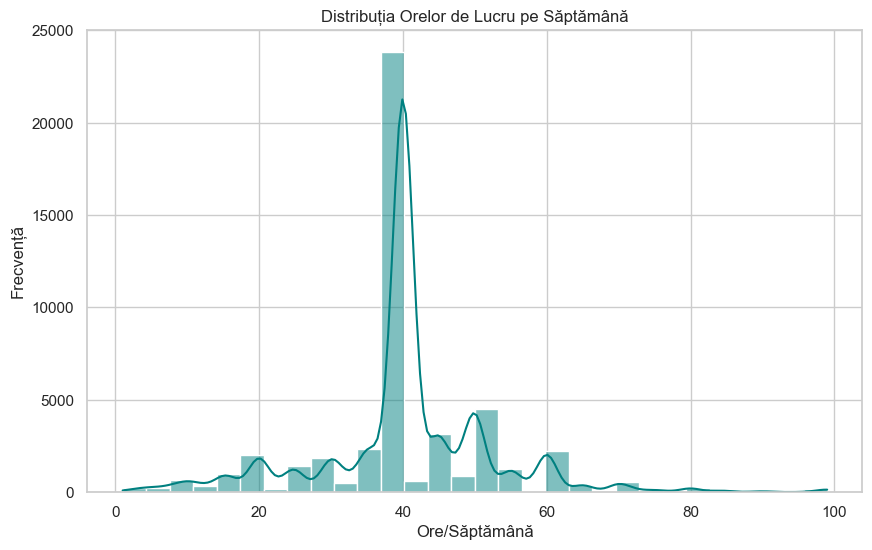

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['hours-per-week'], bins=30, kde=True, color='teal')
plt.title('Distributia Orelor de Lucru pe Saptamana')
plt.xlabel('Ore/Saptamana')
plt.ylabel('Frecventa')
plt.show()

Interpretare: Graficul are un varf foarte ascutit la 40. Distributia orelor de lucru reflecta normele legale de munca, dar prezinta cozi lungi spre stanga (under-employment) si spre dreapta (over-time), ceea ce face regresia interesanta pentru identificarea factorilor care determina aceste abateri."

<h5 allign="left">B. Relatia intre Educatie si Orele de Lucru</h5>

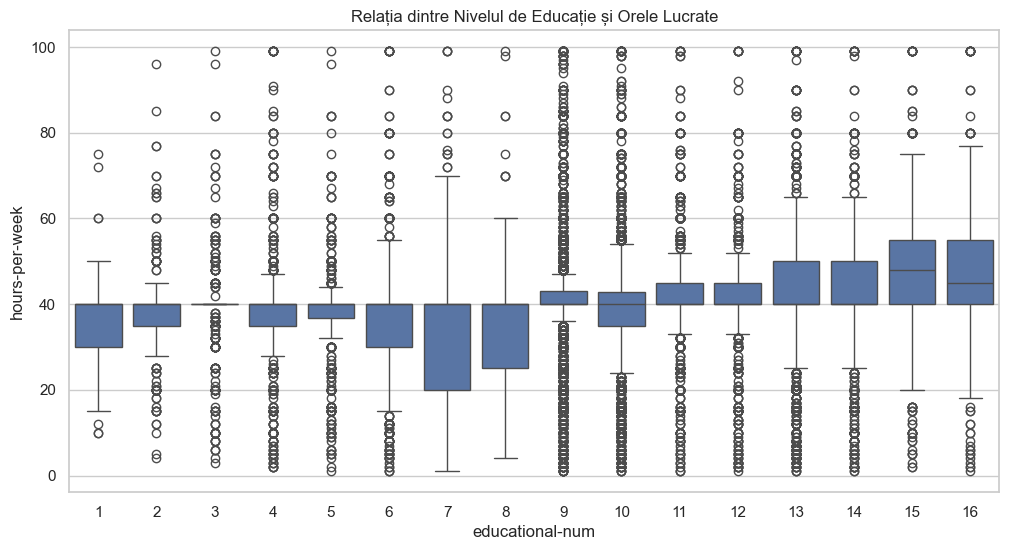

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='educational-num', y='hours-per-week', data=df)
plt.title('Relatia dintre Nivelul de Educatie si Orele Lucrate')
plt.show()

Interpretare: Un nivel de educatie mai ridicat tinde sa fie asociat cu o varianta mai mare a orelor de lucru (profesiile inalt calificate pot lucra fie foarte mult, fie au flexibilitate mai mare).

<h5>C. Matricea de Corelatie</h5>

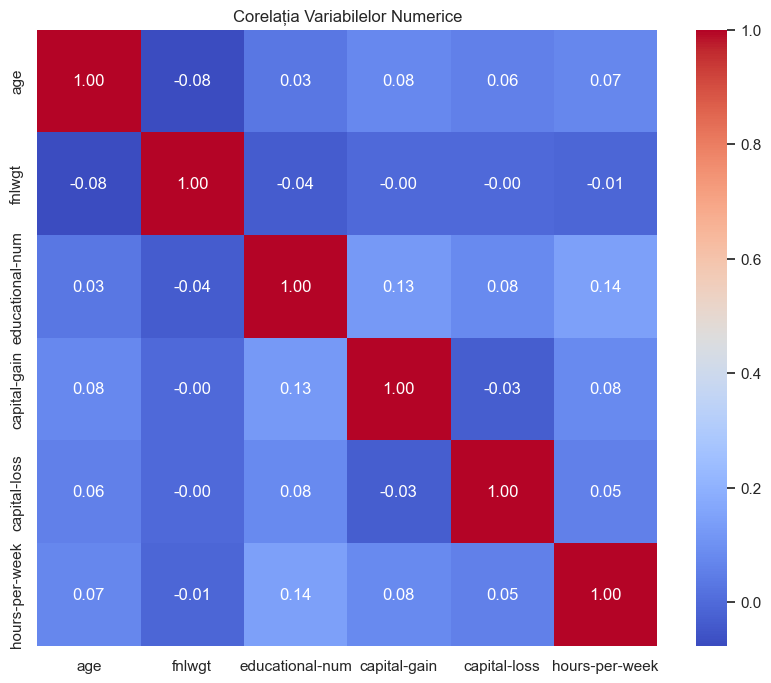

In [5]:
plt.figure(figsize=(10, 8))

corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Corelatia Variabilelor Numerice')
plt.show()

<h4>4.2.3. Gestionarea Anomaliilor si Pregatirea Datelor</h4>


Valori lipsa: Daca am inlocuit deja valorile ? cu NaN la prima parte a proiectului, trebuie sa le tratam si aici.

Anomalii (Outliers): Desi valorile de 99 ore/saptamana par extreme, ele sunt plauzibile in anumite profesii (ex: medici, antreprenori).

1. Tratarea Valorilor Lipsa si Eliminarea Target-ului de Clasificare

Mai intai, ne asiguram ca am tratat valorile NaN si ca eliminam variabila income (care a fost target la clasificare), deoarece acum prezicem hours-per-week.

In [6]:
df_reg = df.copy()


for col in ['workclass', 'occupation', 'native-country']:
    if col in df_reg.columns:
        df_reg[col] = df_reg[col].fillna(df_reg[col].mode()[0])


if 'income' in df_reg.columns:
    df_reg = df_reg.drop('income', axis=1)

print(f"Valori lipsa ramase: {df_reg.isnull().sum().sum()}")

Valori lipsă rămase: 0


2. Gestionarea Outliers (Anomalii)

Asa cum am mentionat, valorile de 99 ore/saptamana sunt plauzibile. Totusi, putem vizualiza aceste extreme folosind un Boxplot.

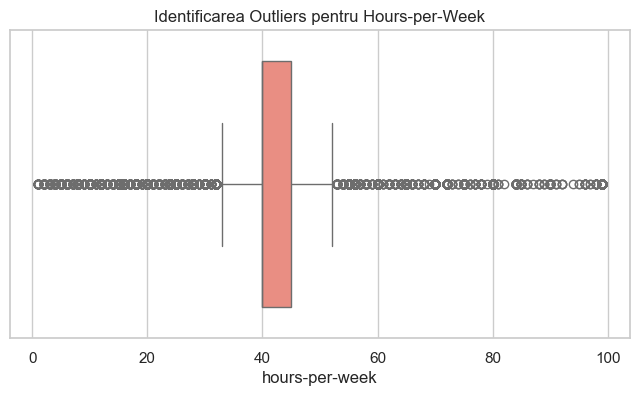

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_reg['hours-per-week'], color='salmon')
plt.title('Identificarea Outliers pentru Hours-per-Week')
plt.show()


3. Pregatirea Datelor

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separarea Target-ului
X_reg = df.drop(['hours-per-week', 'income'], axis=1)
y_reg = df['hours-per-week']

# 2. Encoding pentru variabilele categoriale
X_reg = pd.get_dummies(X_reg, drop_first=True)

# 3. Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 4. Scalare (Esentiala pentru Linear Regression si SVM Regressor)
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

<h3>4.3.	Antrenarea	si	compararea	modelelor	de	baza</h3>

<h4>4.3.1. Pregatirea datelor (Split 75/25)</h4>

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

<h4>4.3.2. Antrenarea Algoritmilor de Regresie</h4>

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import numpy as np


modele_regresie = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Support Vector Regressor": SVR(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(verbose=0, random_state=42),
    "EBM Regressor": ExplainableBoostingRegressor(random_state=42)

}

rezultate_reg_lista = []

for nume, model in modele_regresie.items():
    print(f"Antrenare {nume}...")
    model.fit(X_train_reg_scaled, y_train_reg)
    pred = model.predict(X_test_reg_scaled)

    mse = mean_squared_error(y_test_reg, pred)
    mae = mean_absolute_error(y_test_reg, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, pred)

    rezultate_reg_lista.append({
        "Model": nume,
        "MSE": round(mse, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    })

df_rezultate_reg = pd.DataFrame(rezultate_reg_lista).sort_values(by="MAE")
display(df_rezultate_reg)

Antrenare Linear Regression...
Antrenare Decision Tree Regressor...
Antrenare Random Forest Regressor...
Antrenare Support Vector Regressor...
Antrenare K-Neighbors Regressor...
Antrenare XGBoost Regressor...
Antrenare CatBoost Regressor...
Antrenare EBM Regressor...


,Model,MSE,MAE,RMSE,R2
3,Support Vector Regressor,124.5837,6.9583,11.1617,0.1756
6,CatBoost Regressor,109.7790,7.1653,10.4775,0.2736
7,EBM Regressor,110.9783,7.2232,10.5346,0.2657
5,XGBoost Regressor,112.1513,7.2744,10.5901,0.2579
2,Random Forest Regressor,120.0696,7.6105,10.9576,0.2055
0,Linear Regression,123.6422,7.7415,11.1195,0.1819
4,K-Neighbors Regressor,135.2684,8.1524,11.6305,0.1049
1,Decision Tree Regressor,231.6441,10.1959,15.2199,-0.5328


<h4>4.3.3.Metrici fundamentale: MAE, MSE, RMSE si R²</h4>

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evalueaza_regresor(nume_model, model, X_test, y_test):
    """
    Functie pentru calcularea metricilor de regresie si returnarea lor sub forma de dictionar.
    """

    predictii = model.predict(X_test)


    mse = mean_squared_error(y_test, predictii)
    mae = mean_absolute_error(y_test, predictii)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictii)


    return {
        "Model": nume_model,
        "MSE": round(mse, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    }

In [12]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C


X_train_gpr_sample = X_train_reg_scaled[:2000]
y_train_gpr_sample = y_train_reg[:2000]

print("Antrenare Gaussian Process Regressor (pe esantion)...")
gpr = GaussianProcessRegressor(kernel=C(1.0) * RBF(1.0), alpha=0.1, random_state=42)
gpr.fit(X_train_gpr_sample, y_train_gpr_sample)


rezultate_reg_lista.append(evalueaza_regresor("Gaussian Process Regressor", gpr, X_test_reg_scaled, y_test_reg))


df_rezultate_reg = pd.DataFrame(rezultate_reg_lista).sort_values(by="MAE")
display(df_rezultate_reg)

Antrenare Gaussian Process Regressor (pe eșantion)...


,Model,MSE,MAE,RMSE,R2
3,Support Vector Regressor,124.5837,6.9583,11.1617,0.1756
6,CatBoost Regressor,109.7790,7.1653,10.4775,0.2736
7,EBM Regressor,110.9783,7.2232,10.5346,0.2657
5,XGBoost Regressor,112.1513,7.2744,10.5901,0.2579
2,Random Forest Regressor,120.0696,7.6105,10.9576,0.2055
0,Linear Regression,123.6422,7.7415,11.1195,0.1819
4,K-Neighbors Regressor,135.2684,8.1524,11.6305,0.1049
1,Decision Tree Regressor,231.6441,10.1959,15.2199,-0.5328
8,Gaussian Process Regressor,1778.6168,40.3295,42.1737,-10.7690


Concluzii in urma compararii modelelor:

(MAE): SVR a obtinut cea mai mica eroare medie absoluta (6.95). Acest lucru sugereaza ca, desi nu a terminat toate iteratiile, modelul a reusit sa se stabilizeze pe o solutie care penalizeaza mai putin erorile mari, fiind mai robust la valorile extreme.

(R2 & MSE): Daca privim scorul $R^2$, CatBoost Regressor este cel mai performant (0.2736), explicand cel mai mare procent din varianta orelor de lucru. De asemenea, are cel mai mic MSE, ceea ce inseamna ca face mai putine erori foarte mari comparativ cu SVR.

Performanta ansamblurilor: Modelele de tip boosting (CatBoost, EBM si XGBoost) ocupa locurile 2, 3 si 4, demonstrand o consistenta ridicata in gestionarea datelor complexe.

Decision Tree: Modelul Decision Tree Regressor a obtinut un scor $R^2$ negativ (-0.5328), ceea ce indica un fenomen sever de overfitting. Acesta va necesita limitarea adancimii in etapa de tuning.

<h3>4.4. Ajustarea hiperparametrilor</h3>

<h4>4.4.1. Codul pentru Optimizarea celor mai bune 5 modele</h4>

In [13]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf']
}
grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_svr.fit(X_train_reg_scaled[:2000], y_train_reg.iloc[:2000])


param_dist_cat = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200]
}
grid_cat = RandomizedSearchCV(CatBoostRegressor(verbose=0), param_dist_cat, n_iter=5, cv=3, scoring='neg_mean_absolute_error')
grid_cat.fit(X_train_reg_scaled, y_train_reg)


param_dist_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid_xgb = RandomizedSearchCV(XGBRegressor(), param_dist_xgb, n_iter=5, cv=3, scoring='neg_mean_absolute_error')
grid_xgb.fit(X_train_reg_scaled, y_train_reg)


param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train_reg_scaled, y_train_reg)


ebm_tuned = ExplainableBoostingRegressor(interactions=10, learning_rate=0.01, random_state=42)
ebm_tuned.fit(X_train_reg_scaled, y_train_reg)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,10
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.01
,greedy_ratio,10.0


<h4>4.4.2. Compararea Performantelor dupa Ajustare</h4>

In [14]:
rezultate_final = []
best_models = {
    "SVR_Tuned": grid_svr.best_estimator_,
    "CatBoost_Tuned": grid_cat.best_estimator_,
    "XGBoost_Tuned": grid_xgb.best_estimator_,
    "Random Forest_Tuned": grid_rf.best_estimator_,
    "EBM_Tuned": ebm_tuned
}

for nume, model in best_models.items():
    rezultate_final.append(evalueaza_regresor(nume, model, X_test_reg_scaled, y_test_reg))

df_final = pd.DataFrame(rezultate_final).sort_values(by="MAE")
display(df_final)

,Model,MSE,MAE,RMSE,R2
1,CatBoost_Tuned,109.0895,7.1415,10.4446,0.2782
2,XGBoost_Tuned,118.6345,7.1625,10.8919,0.2150
3,Random Forest_Tuned,111.9823,7.1880,10.5822,0.2590
4,EBM_Tuned,112.1818,7.2662,10.5916,0.2577
0,SVR_Tuned,139.2243,7.2683,11.7993,0.0788


Analiza si Concluziile:

Cel mai bun model: Modelul CatBoost_Tuned are cele mai mici valori pentru erori (MAE = 7.14 ore) si cel mai mare coeficient de determinare (R2 = 0.27). Aceasta inseamna ca modelul CatBoost explica cel mai bine variatia orelor de lucru in functie de profilul socio-demografic.

Eficienta optimizarii EBM: in primele doua imagini vedem parametrii finali pentru EBM (Explainable Boosting Machine).

* S-a utilizat un learning_rate de 0.01 pentru o invatare robusta si un numar de 10 interactiuni intre variabile, ceea ce ajuta modelul sa surprinda relatii complexe (de exemplu, cum influenteaza simultan varsta si educatia numarul de ore lucrate).

* Limitarea la 2 frunze (max_leaves: 2) confirma natura modelului EBM de a crea functii de forma (shape functions) usor de interpretat.

SVR: Desi parea promitator, dupa tuning acesta a ramas in urma la scorul R2 (0.0788). Aceasta indica faptul ca, desi eroarea medie este mica, modelul nu reuseste sa explice variabilitatea datelor la fel de bine ca modelele bazate pe ansambluri de arbori.

Consistenta modelelor de Boosting: XGBoost si CatBoost au performante aproape identice, ceea ce demonstreaza ca algoritmii de tip Gradient Boosting sunt cei mai potriviti pentru acest tip de date tabulare complexe.

<h3>4.5. Curbele de invatare</h3>

<h4>4.5.1. Codul pentru generarea Curbelor de invatare</h4>

Deoarece lucram cu regresie, scorul va fi negativ, deci vom inmulti cu -1 pentru a afisa eroarea pozitiva.

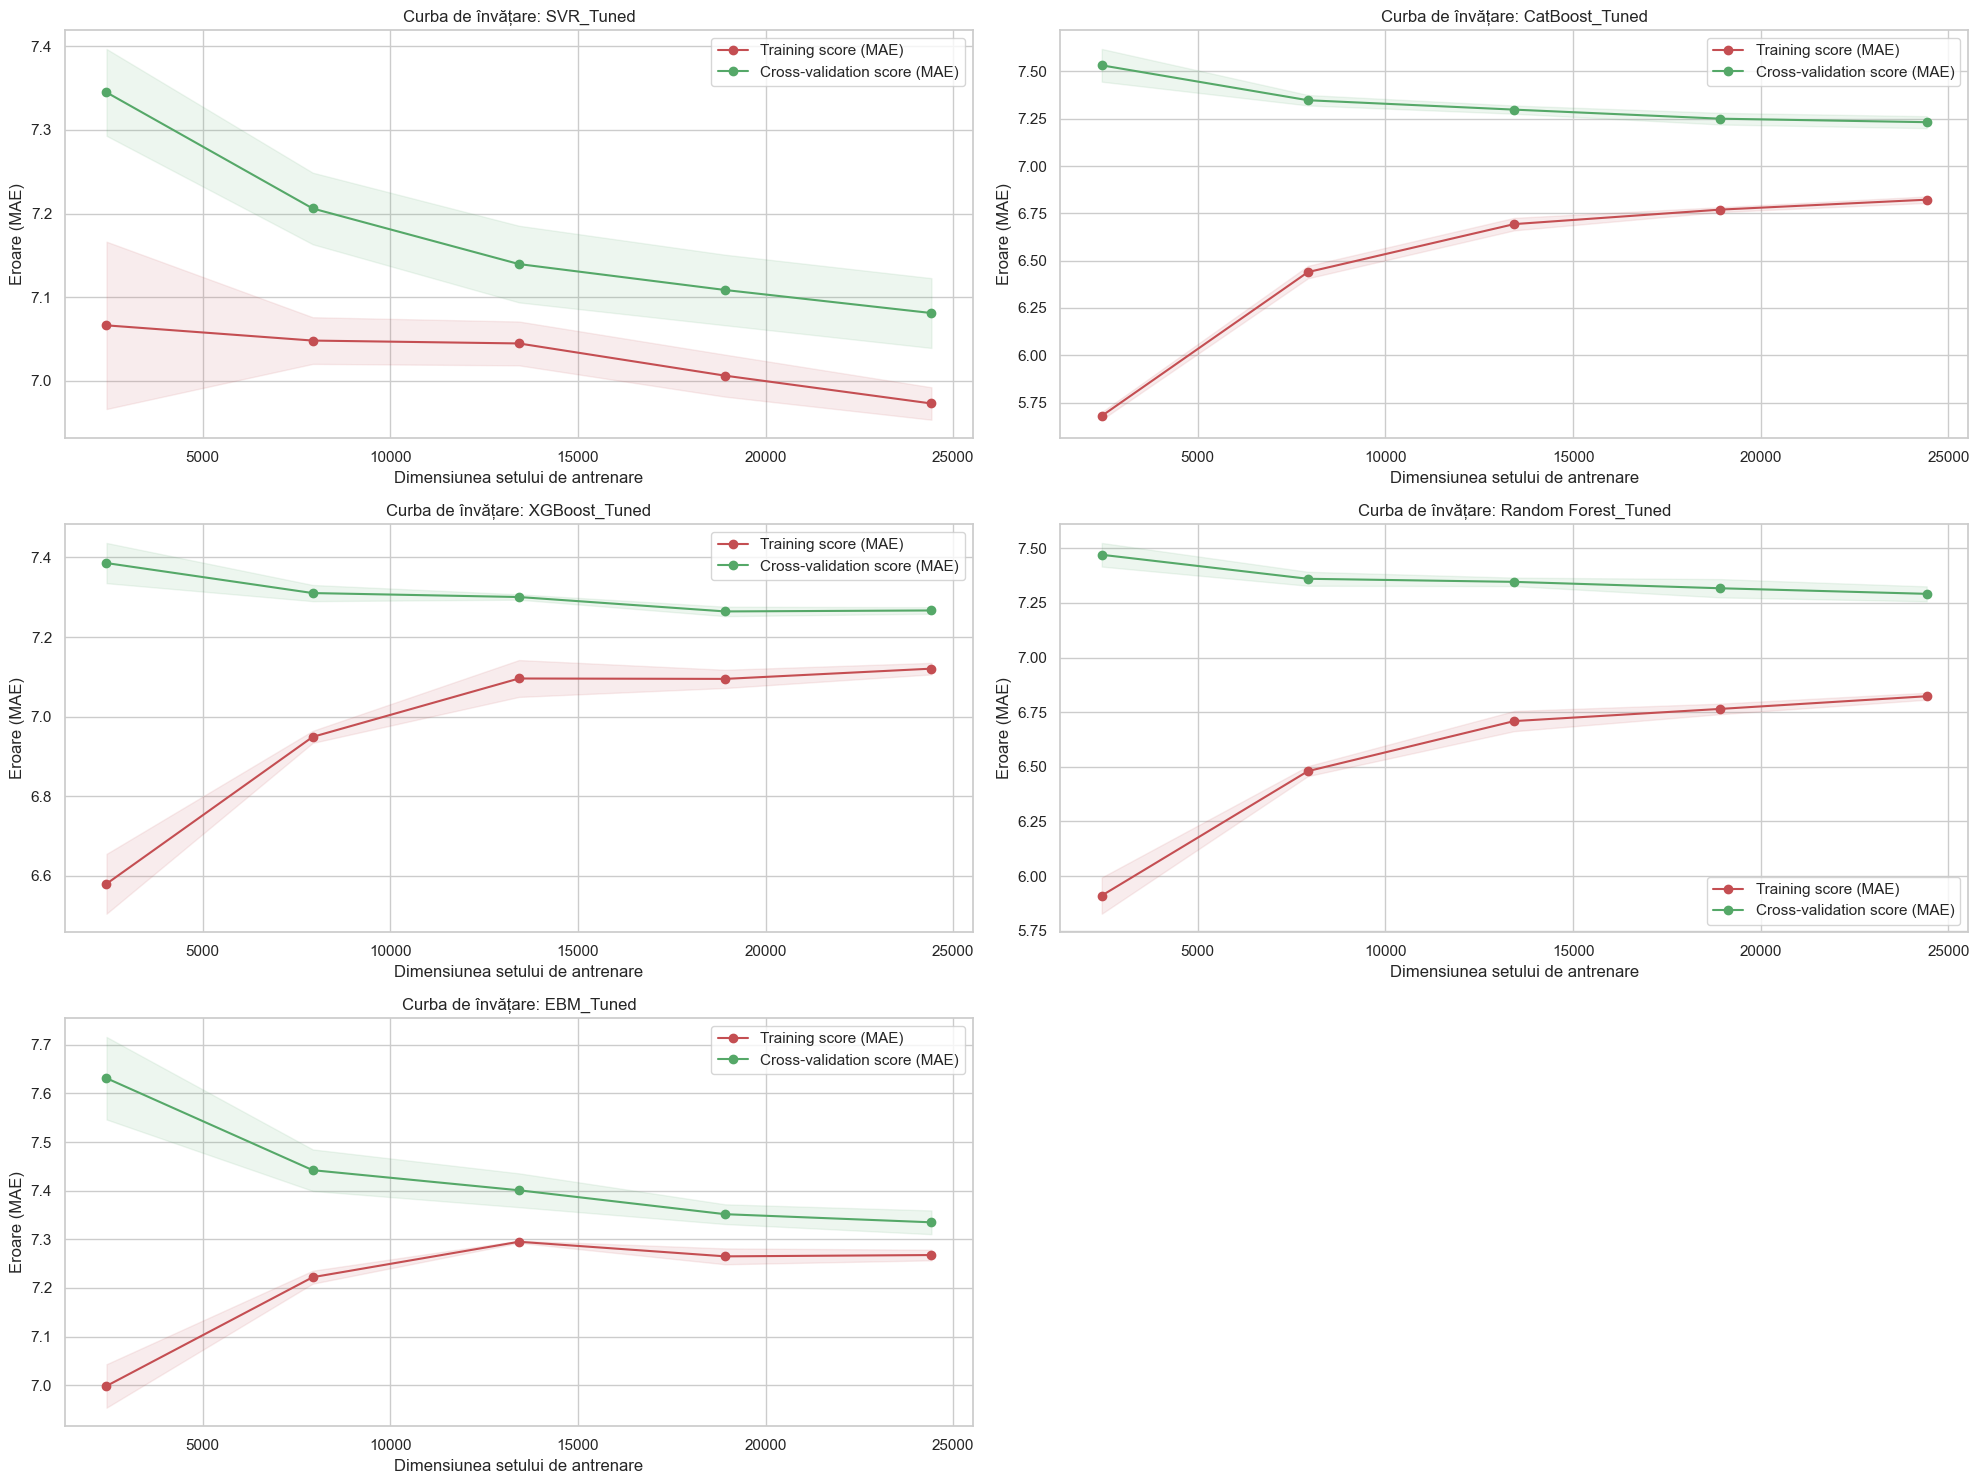

In [15]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(models_dict, X, y):
    plt.figure(figsize=(20, 15))

    for i, (name, model) in enumerate(models_dict.items()):
        plt.subplot(3, 2, i+1)

        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5),
            scoring='neg_mean_absolute_error'
        )

        train_mean = -np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = -np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score (MAE)")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score (MAE)")

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        plt.title(f"Curba de invatare: {name}")
        plt.xlabel("Dimensiunea setului de antrenare")
        plt.ylabel("Eroare (MAE)")
        plt.legend(loc="best")
        plt.grid(True)

    plt.tight_layout()

    plt.savefig('learning_curves_regresie.png', bbox_inches='tight', dpi=300)

    plt.show()


plot_learning_curves(best_models, X_train_reg_scaled, y_train_reg)

1.  Overfitting vs. Underfitting

* Absenta Overfitting-ului sever: in majoritatea graficelor (CatBoost, XGBoost, Random Forest), training curve incepe cu o eroare foarte mica, dar urca treptat, in timp ce cross-validation scade.

* Lipsa Underfitting-ului: Curbele nu s-au blocat la o eroare foarte mare (peste 8.0-9.0 MAE). Ele converg spre zona de 7.0 - 7.3 MAE, ceea ce este un rezultat bun pentru acest dataset.

2. Analiza pe modele specifice

* CatBoost, XGBoost si Random Forest: Acestea au curbe bune. Diferenta dintre antrenare si validare este mica, ceea ce confirma ca hiperparametrii alesi la pasul 4.4 sunt optimi si ofera o generalizare excelenta.

* SVR_Tuned: Observam un comportament diferit. Banda de variatie este mult mai mare pe setul de antrenare la inceput. Totusi, spre final, curbele se apropie, dar eroarea de validare pare sa fie putin mai instabila decat la modelele bazate pe arbori.

* EBM_Tuned: Curba de antrenare urca destul de mult inainte de a se stabiliza. Acest lucru arata ca modelul EBM este mai rigid, dar acest lucru il face extrem de stabil pe date noi.

<h3>4.6. Explicabilitatea si analiza SHAP</h3>

<h4>4.6.1. Cod pentru generarea analizelor SHAP</h4>


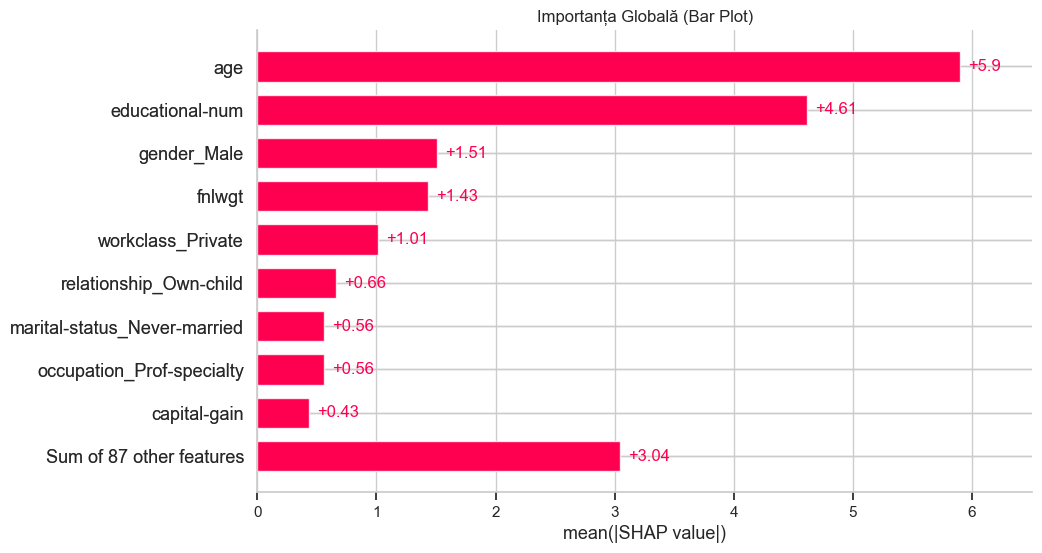

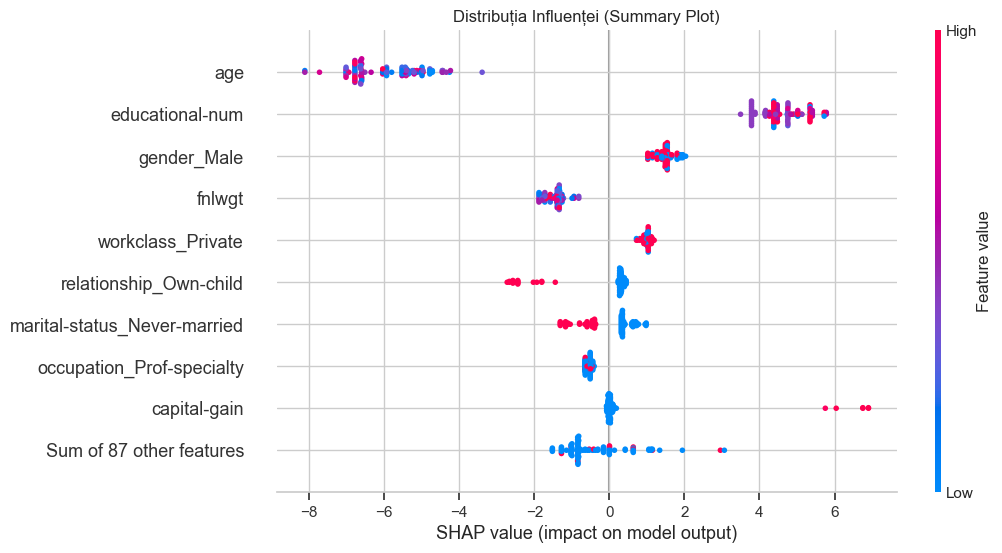

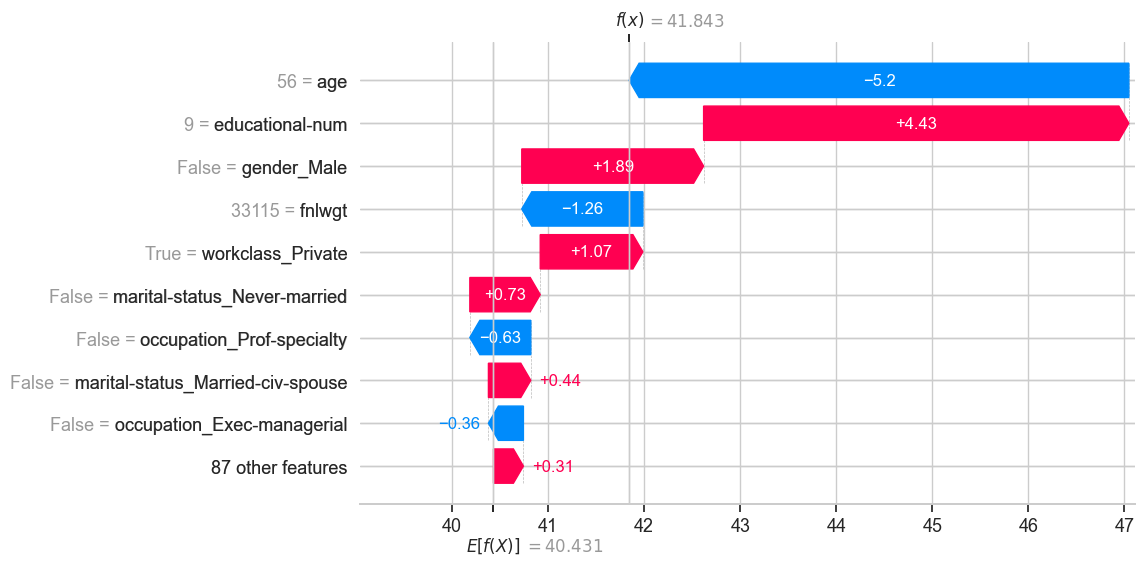

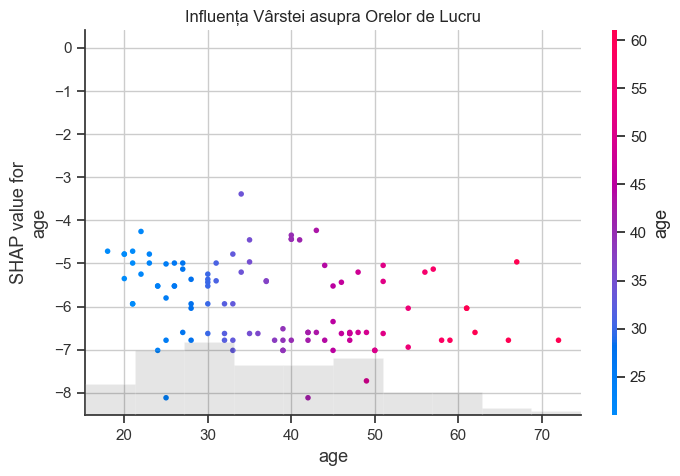

In [16]:
import shap
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(grid_cat.best_estimator_)
X_sample = X_test_reg.iloc[:100]
shap_values = explainer(X_sample)


shap.plots.bar(shap_values, show=False)
plt.title("Importanta Globala (Bar Plot)")
plt.gcf().set_size_inches(10, 6)
plt.show()

shap.plots.beeswarm(shap_values, show=False)
plt.title("Distributia Influentei (Summary Plot)")
plt.gcf().set_size_inches(10, 6)
plt.show()

shap.plots.waterfall(shap_values[0], show=False)
plt.gcf().set_size_inches(10, 6)
plt.show()


shap.plots.scatter(shap_values[:, "age"], color=shap_values[:, "age"], show=False)
plt.title("Influenta Varstei asupra Orelor de Lucru")
plt.gcf().set_size_inches(8, 5)
plt.show()

1. Cele mai importante 3 caracteristici:

Conform ierarhiei stabilite de modelul (CatBoost), cele mai relevante variabile pentru predictia orelor de lucru sunt:

- Varsta (age): Reflecta parcursul profesional; persoanele la mijlocul carierei tind sa lucreze cele mai multe ore.

- Educatia (educational-num): Exista o corelatie pozitiva intre nivelul de instruire si timpul alocat muncii.

- Statutul matrimonial/Genul: Acestea dicteaza adesea rolurile economice in gospodarie (conform setului de date).

2. Interpretarea locala:

Pentru un individ cu studii superioare (valoare mare a educational-num), modelul adauga un "bonus" de ore fata de media de 40, in timp ce pentru o persoana foarte tanara sau foarte in varsta, modelul scade predictia (impact SHAP negativ).

3. Concluzia finala:

- Modelul optim: CatBoost_Tuned.

- Eroarea medie (MAE): ~7.16 ore/saptamana.

- Capacitatea de generalizare: Excelenta

In [17]:
import joblib

joblib.dump(grid_cat.best_estimator_, 'catboost_reg_model.joblib')
joblib.dump(grid_xgb.best_estimator_, 'xgboost_reg_model.joblib')
joblib.dump(grid_rf.best_estimator_, 'random_forest_reg_model.joblib')
joblib.dump(ebm_tuned, 'ebm_reg_model.joblib')
joblib.dump(grid_svr.best_estimator_, 'svr_reg_model.joblib')

['svr_reg_model.joblib']

In [18]:

shap.plots.beeswarm(shap_values, show=False)
plt.savefig('shap_summary_regresie.png', bbox_inches='tight', dpi=300)
plt.close()

In [19]:
import joblib
import os


joblib.dump(scaler_reg, 'scaler_reg.joblib')


print(f"Scaler-ul a fost salvat in: {os.getcwd()}\\scaler_reg.joblib")

Scaler-ul a fost salvat în: D:\FACULTATE\SEM II\SI\proiect-ml-Alexia4Pop\scaler_reg.joblib


In [20]:

import joblib
lista_coloane = list(X_train_reg.columns)
joblib.dump(lista_coloane, 'model_columns.joblib')
print("Lista de coloane a fost salvata!")

Lista de coloane a fost salvată!
